# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [33]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/vitor-michelucci/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminho da base construída no notebook 00
DATA_PATH = PROJECT_PATH / "data" / "processed" / "dataset_base.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("\nDiretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Repositório já disponível nesta sessão.

Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [3]:
# Gera a base analítica necessária para o EDA
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/00_preparacao_dados.ipynb" \
    --output "/tmp/00_preparacao_dados_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/00_preparacao_dados.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] Writing 105602 bytes to /tmp/00_preparacao_dados_executado.ipynb


In [4]:
# ============================================================
# VERIFICAÇÃO DA BASE GERADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)

Arquivo existe: True
Tamanho do arquivo: 3.97 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [5]:
# ============================================================
# 2. CARREGAMENTO DA BASE ANALÍTICA
# ============================================================

# Verifica se a base produzida pelo notebook 00 está disponível
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "O arquivo dataset_base.csv não foi encontrado. "
        "Execute primeiro o notebook 00_preparacao_dados.ipynb "
        "para gerar a base analítica."
    )

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (33110, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [7]:
# ============================================================
# 3. VISÃO GERAL DA BASE
# ============================================================

print("Número de registros:", df.shape[0])
print("Número de variáveis:", df.shape[1])
print("Número de clientes:", df["ID"].nunique())

print("\nTipos das variáveis:")
print(df.dtypes.value_counts())

print("\nValores ausentes:")
print(df.isna().sum().sort_values(ascending=False).head())

percentual_ausente = (
    df["OCCUPATION_TYPE"].isna().mean() * 100
)

print(
    f"\nPercentual ausente em OCCUPATION_TYPE: "
    f"{percentual_ausente:.2f}%"
)

Número de registros: 33110
Número de variáveis: 19
Número de clientes: 33110

Tipos das variáveis:
int64      9
object     8
float64    2
Name: count, dtype: int64

Valores ausentes:
OCCUPATION_TYPE    10373
CODE_GENDER            0
ID                     0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
dtype: int64

Percentual ausente em OCCUPATION_TYPE: 31.33%


### Interpretação

A base analítica contém 33.110 registros e 33.110 clientes distintos, indicando que cada linha representa um único cliente. O conjunto possui 19 variáveis, sendo 11 numéricas (`int64` ou `float64`) e 8 categóricas (`object`).

Em relação à completude dos dados, a única variável com valores ausentes é `OCCUPATION_TYPE`, com 10.373 registros sem informação, correspondentes a 31,33% da base. Por representar uma parcela relevante das observações, esses registros não serão simplesmente excluídos nesta etapa. A estratégia de tratamento será avaliada posteriormente no pré-processamento.

In [8]:
# ============================================================
# 4. IDENTIFICAÇÃO DOS TIPOS DE VARIÁVEIS
# ============================================================

variaveis_numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variaveis_categoricas = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variáveis armazenadas como numéricas:")
print(variaveis_numericas)

print("\nVariáveis armazenadas como categóricas:")
print(variaveis_categoricas)

Variáveis armazenadas como numéricas:
['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'target']

Variáveis armazenadas como categóricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [9]:
# ============================================================
# 5. QUANTIDADE DE VALORES ÚNICOS POR VARIÁVEL
# ============================================================

valores_unicos = (
    df.nunique()
    .sort_values()
)

print(valores_unicos)

FLAG_MOBIL                 1
CODE_GENDER                2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_PHONE                 2
FLAG_WORK_PHONE            2
FLAG_EMAIL                 2
target                     2
NAME_FAMILY_STATUS         5
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_HOUSING_TYPE          6
CNT_CHILDREN               9
CNT_FAM_MEMBERS           10
OCCUPATION_TYPE           18
AMT_INCOME_TOTAL         258
DAYS_EMPLOYED           3566
DAYS_BIRTH              6960
ID                     33110
dtype: int64


### Classificação das variáveis

A análise da cardinalidade mostra que o tipo de armazenamento das variáveis não corresponde necessariamente à sua natureza estatística.

A variável `ID` funciona exclusivamente como identificador do cliente e não deve ser interpretada como uma variável quantitativa. O `target` e as variáveis `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE` e `FLAG_EMAIL` são binárias, embora estejam armazenadas como números inteiros.

Entre essas variáveis, `FLAG_MOBIL` apresenta apenas um valor em toda a base, não possuindo variabilidade entre os clientes. Por esse motivo, sua utilidade para a modelagem deverá ser avaliada na etapa de pré-processamento.

As demais variáveis representam características quantitativas ou categóricas dos clientes e serão analisadas de acordo com sua natureza durante a análise exploratória.

In [10]:
# ============================================================
# 6. AGRUPAMENTO DAS VARIÁVEIS PARA O EDA
# ============================================================

IDENTIFICADOR = "ID"

variaveis_quantitativas = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

variaveis_binarias = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "FLAG_MOBIL",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]

variaveis_categoricas = [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

print("Quantitativas:", len(variaveis_quantitativas))
print("Binárias:", len(variaveis_binarias))
print("Categóricas:", len(variaveis_categoricas))
print("Target:", TARGET)
print("Identificador:", IDENTIFICADOR)

Quantitativas: 5
Binárias: 7
Categóricas: 5
Target: target
Identificador: ID


## 2 — Análise das variáveis quantitativas

Nesta etapa são analisadas as distribuições e estatísticas descritivas das variáveis quantitativas. O objetivo é identificar características relevantes, possíveis assimetrias, valores extremos e situações que necessitem de investigação antes do pré-processamento.

In [11]:
# ============================================================
# 7. ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS QUANTITATIVAS
# ============================================================

estatisticas_quantitativas = (
    df[variaveis_quantitativas]
    .describe()
    .T
)

estatisticas_quantitativas

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,33110.0,0.427756,0.741716,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,33110.0,185877.170704,101412.408324,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,33110.0,-16007.262489,4213.387673,-25152.0,-19495.0,-15646.0,-12461.0,-7705.0
DAYS_EMPLOYED,33110.0,60031.029085,138345.184712,-15713.0,-3159.0,-1552.0,-405.0,365243.0
CNT_FAM_MEMBERS,33110.0,2.194654,0.911076,1.0,2.0,2.0,3.0,20.0


In [12]:
# ============================================================
# 8. INVESTIGAÇÃO DE DAYS_EMPLOYED
# ============================================================

print("Maiores valores de DAYS_EMPLOYED:")
print(
    df["DAYS_EMPLOYED"]
    .value_counts()
    .sort_index(ascending=False)
    .head(10)
)

print("\nQuantidade de valores positivos:")
print((df["DAYS_EMPLOYED"] > 0).sum())

print("\nPercentual de valores positivos:")
print(
    round(
        (df["DAYS_EMPLOYED"] > 0).mean() * 100,
        2
    )
)

Maiores valores de DAYS_EMPLOYED:
DAYS_EMPLOYED
 365243    5642
-17           3
-43           1
-65           2
-70           4
-71           1
-73          17
-78           1
-79           1
-88           2
Name: count, dtype: int64

Quantidade de valores positivos:
5642

Percentual de valores positivos:
17.04


### Análise de `DAYS_EMPLOYED`

A variável `DAYS_EMPLOYED` apresenta uma característica relevante. Embora a maior parte dos registros possua valores negativos, compatíveis com a representação do tempo de emprego em dias anteriores à data de referência, foram identificados 5.642 registros com o valor positivo `365243`, correspondentes a 17,04% da base.

Todos os valores positivos encontrados estão concentrados nesse mesmo valor. Considerando sua magnitude, `365243` não representa um tempo de emprego plausível e deve ser interpretado como um valor especial presente na base.

A presença desse código afeta diretamente estatísticas como a média de `DAYS_EMPLOYED`, que se torna pouco representativa da distribuição real. O tratamento desses registros será definido posteriormente na etapa de pré-processamento.

In [13]:
# ============================================================
# 9. INVESTIGAÇÃO DA COMPOSIÇÃO FAMILIAR
# ============================================================

print("Distribuição de CNT_CHILDREN:")
print(
    df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição de CNT_FAM_MEMBERS:")
print(
    df["CNT_FAM_MEMBERS"]
    .value_counts()
    .sort_index()
)

Distribuição de CNT_CHILDREN:
CNT_CHILDREN
0     22959
1      6731
2      2967
3       380
4        52
5        15
7         2
14        3
19        1
Name: count, dtype: int64

Distribuição de CNT_FAM_MEMBERS:
CNT_FAM_MEMBERS
1.0      6366
2.0     17759
3.0      5718
4.0      2837
5.0       362
6.0        48
7.0        14
9.0         2
15.0        3
20.0        1
Name: count, dtype: int64


In [14]:
# ============================================================
# 10. VERIFICAÇÃO DOS CASOS EXTREMOS DE COMPOSIÇÃO FAMILIAR
# ============================================================

casos_extremos_familia = df.loc[
    (df["CNT_CHILDREN"] >= 7) |
    (df["CNT_FAM_MEMBERS"] >= 9),
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].sort_values(
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"],
    ascending=False
)

casos_extremos_familia

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
23031,5105054,19,20.0,Single / not married
13323,5061207,14,15.0,Separated
13324,5061210,14,15.0,Separated
13325,5061211,14,15.0,Separated
27004,5118330,7,9.0,Married
27005,5118331,7,9.0,Married


### Análise da composição familiar

As variáveis `CNT_CHILDREN` e `CNT_FAM_MEMBERS` apresentam distribuições concentradas em valores baixos, mas foram identificados poucos registros com valores elevados.

A inspeção dos casos extremos mostrou coerência entre as duas variáveis. O cliente com 19 filhos possui 20 membros familiares, enquanto os registros com 14 filhos possuem 15 membros e os registros com 7 filhos possuem 9 membros familiares.

Embora esses valores sejam raros e possam influenciar algumas medidas estatísticas, a consistência entre o número de filhos e o tamanho da família não fornece evidência suficiente para classificá-los como erros. Dessa forma, os registros serão mantidos nesta etapa e seu eventual tratamento será avaliado posteriormente.

In [15]:
# ============================================================
# 11. INVESTIGAÇÃO DA RENDA
# ============================================================

print("Quantis de AMT_INCOME_TOTAL:")

print(
    df["AMT_INCOME_TOTAL"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
)

print("\n10 maiores valores de renda:")

print(
    df["AMT_INCOME_TOTAL"]
    .nlargest(10)
)

Quantis de AMT_INCOME_TOTAL:
0.50     157500.0
0.75     225000.0
0.90     310500.0
0.95     360000.0
0.99     560250.0
1.00    1575000.0
Name: AMT_INCOME_TOTAL, dtype: float64

10 maiores valores de renda:
30834    1575000.0
30835    1575000.0
30836    1575000.0
30837    1575000.0
30838    1575000.0
30839    1575000.0
30840    1575000.0
30841    1575000.0
653      1350000.0
654      1350000.0
Name: AMT_INCOME_TOTAL, dtype: float64


### Análise da renda

A variável `AMT_INCOME_TOTAL` apresenta assimetria à direita, com presença de valores elevados na cauda superior da distribuição.

A mediana da renda total é 157.500, enquanto 95% dos registros apresentam valores de até 360.000 e 99% de até 560.250. O valor máximo observado é 1.575.000, substancialmente superior aos principais quantis da distribuição.

Os maiores valores aparecem em mais de um registro e, nesta etapa, não há evidência suficiente para classificá-los como erros. Esses valores serão mantidos durante a análise exploratória, e seu impacto sobre o pré-processamento e a modelagem será avaliado posteriormente.

In [16]:
# ============================================================
# 12. CONVERSÃO DE DAYS_BIRTH PARA IDADE
# ============================================================

# Cria uma variável apenas para facilitar a interpretação no EDA.
# A variável original é preservada.
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25)

print(df["AGE_YEARS"].describe().round(2))

count    33110.00
mean        43.83
std         11.54
min         21.10
25%         34.12
50%         42.84
75%         53.37
max         68.86
Name: AGE_YEARS, dtype: float64


### Análise da idade

A variável `DAYS_BIRTH` foi convertida para idade aproximada em anos apenas para facilitar sua interpretação durante a análise exploratória, preservando-se a variável original.

A população analisada possui idade entre aproximadamente 21 e 69 anos, com média de 43,83 anos e mediana de 42,84 anos. Os valores observados apresentam uma faixa etária plausível, não sendo identificadas, nesta análise inicial, idades incompatíveis com a população estudada.

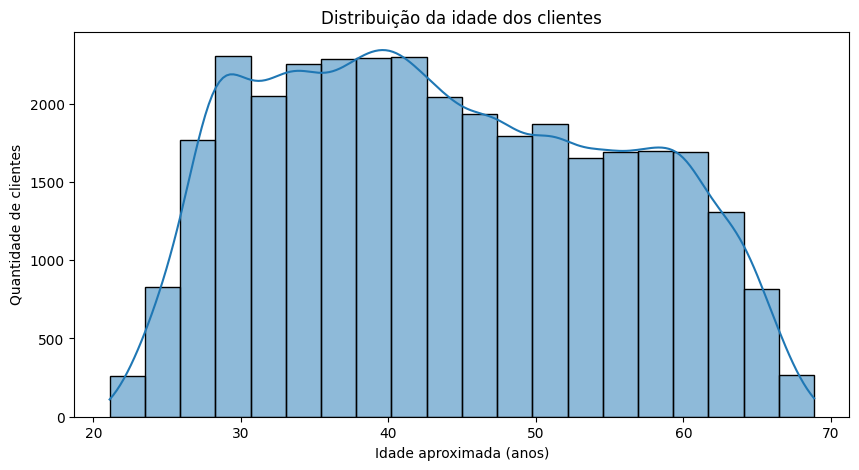

In [17]:
# ============================================================
# 13. DISTRIBUIÇÃO DA IDADE
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AGE_YEARS",
    bins=20,
    kde=True
)

plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade aproximada (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

A distribuição das idades abrange aproximadamente 21 a 69 anos, com maior concentração de clientes nas faixas etárias intermediárias. Visualmente, observa-se maior frequência aproximadamente entre 28 e 45 anos, seguida de redução gradual nas idades mais elevadas.

A distribuição não apresenta valores isolados ou descontinuidades evidentes que indiquem possíveis inconsistências na variável idade. A média de 43,83 anos e a mediana de 42,84 anos também são relativamente próximas, indicando que essas medidas de tendência central apresentam comportamento semelhante na amostra.

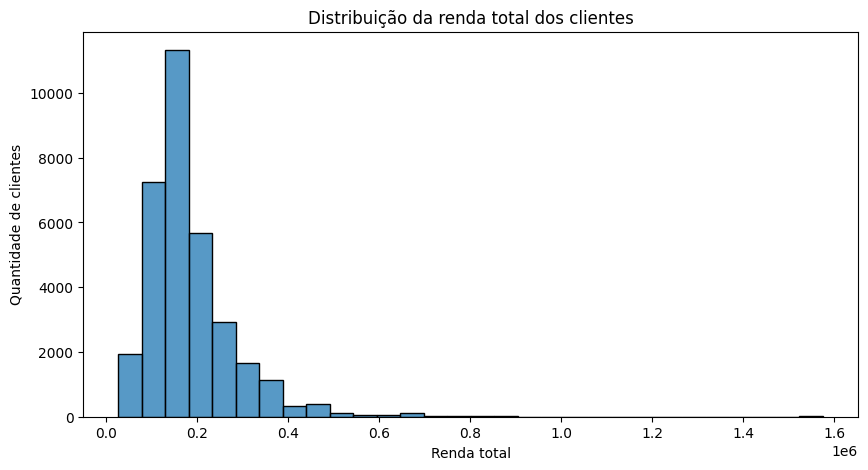

In [18]:
# ============================================================
# 14. DISTRIBUIÇÃO DA RENDA TOTAL
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total dos clientes")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

A distribuição da renda total apresenta forte assimetria à direita. A maior parte dos clientes está concentrada nas faixas inferiores e intermediárias de renda, enquanto uma quantidade reduzida de observações com valores elevados forma uma cauda longa à direita.

A presença desses valores extremos amplia significativamente a escala do gráfico e dificulta a visualização detalhada da região onde se concentra a maior parte dos clientes. Por esse motivo, será utilizada também uma visualização complementar limitada ao percentil 99 da renda, sem excluir ou modificar os registros da base original.

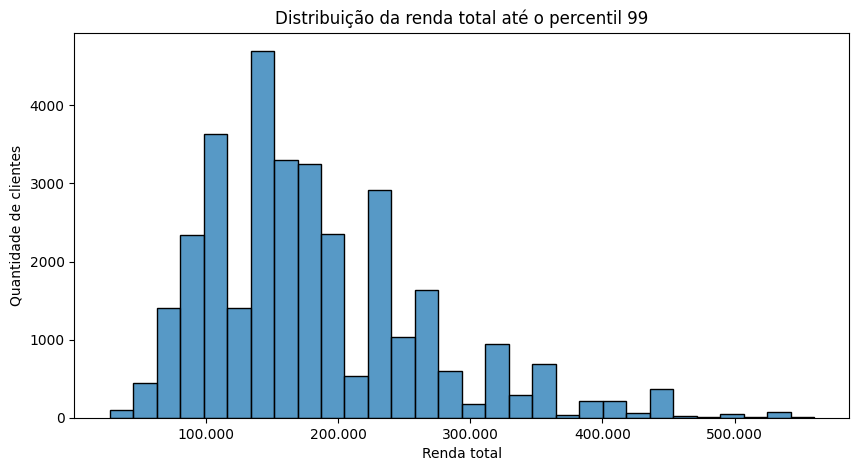

Percentil 99 da renda: 560,250.00


In [20]:
# ============================================================
# 15. DISTRIBUIÇÃO DA RENDA ATÉ O PERCENTIL 99
# ============================================================

limite_renda_99 = df["AMT_INCOME_TOTAL"].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["AMT_INCOME_TOTAL"] <= limite_renda_99],
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total até o percentil 99")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.show()

print(f"Percentil 99 da renda: {limite_renda_99:,.2f}")

### Interpretação da distribuição até o percentil 99

A visualização limitada ao percentil 99 permite observar com maior detalhe a região em que se concentra a maior parte dos clientes. Mesmo desconsiderando visualmente o 1% de maiores valores, a distribuição permanece assimétrica à direita, com maior concentração nas faixas inferiores e intermediárias de renda e redução da frequência à medida que os valores aumentam.

Também são observadas concentrações em determinados níveis de renda, indicando a ocorrência recorrente de alguns valores no conjunto de dados. A limitação ao percentil 99 foi aplicada exclusivamente para fins de visualização e não representa exclusão de observações da base.

In [21]:
# ============================================================
# 16. TEMPO DE EMPREGO EM ANOS
# ============================================================

# Considera somente os valores negativos de DAYS_EMPLOYED.
# O código especial 365243 não entra neste cálculo.
tempo_emprego_valido = df.loc[
    df["DAYS_EMPLOYED"] < 0,
    "DAYS_EMPLOYED"
]

tempo_emprego_anos = -tempo_emprego_valido / 365.25

print("Registros com tempo de emprego válido:", len(tempo_emprego_anos))
print("\nEstatísticas do tempo de emprego (anos):")
print(tempo_emprego_anos.describe().round(2))

Registros com tempo de emprego válido: 27468

Estatísticas do tempo de emprego (anos):
count    27468.00
mean         7.28
std          6.49
min          0.05
25%          2.68
50%          5.46
75%          9.64
max         43.02
Name: DAYS_EMPLOYED, dtype: float64


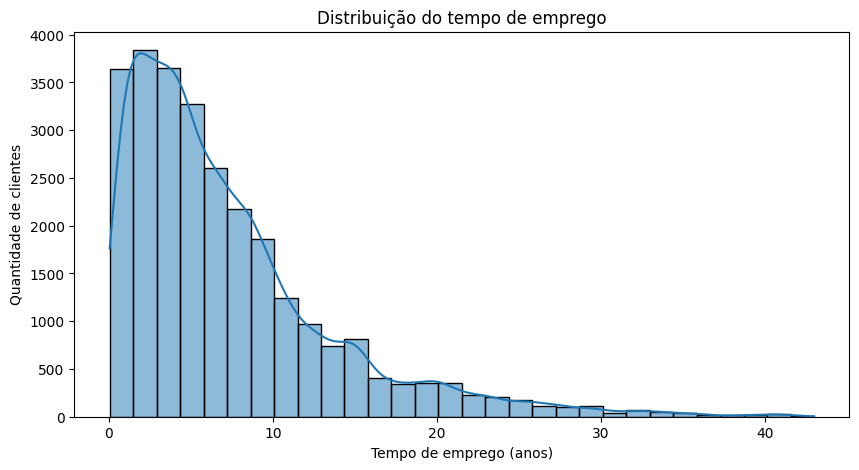

In [22]:
# ============================================================
# 17. DISTRIBUIÇÃO DO TEMPO DE EMPREGO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    x=tempo_emprego_anos,
    bins=30,
    kde=True
)

plt.title("Distribuição do tempo de emprego")
plt.xlabel("Tempo de emprego (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

Considerando apenas os 27.468 registros com valores interpretáveis de `DAYS_EMPLOYED`, observa-se uma distribuição assimétrica à direita. A maior concentração de clientes ocorre nos menores tempos de emprego, enquanto a frequência diminui progressivamente à medida que o tempo de vínculo aumenta.

A mediana do tempo de emprego é de aproximadamente 5,46 anos, enquanto a média é de 7,28 anos, diferença compatível com a presença de uma cauda longa à direita. O maior tempo observado entre os registros válidos é de aproximadamente 43 anos.

Os 5.642 registros originalmente codificados como `365243`, correspondentes a 17,04% da base, não foram incluídos nesta visualização, pois esse valor não representa um tempo de emprego plausível. Os registros permanecem preservados na base original e seu tratamento será definido na etapa de pré-processamento.

In [23]:
# ============================================================
# 18. RELAÇÃO ENTRE FILHOS E TAMANHO DA FAMÍLIA
# ============================================================

correlacao_familia = df[
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
].corr()

print(correlacao_familia)

                 CNT_CHILDREN  CNT_FAM_MEMBERS
CNT_CHILDREN         1.000000         0.888412
CNT_FAM_MEMBERS      0.888412         1.000000


### Relação entre número de filhos e tamanho da família

As variáveis `CNT_CHILDREN` e `CNT_FAM_MEMBERS` apresentam correlação de aproximadamente 0,89, indicando forte associação linear positiva. Esse comportamento é coerente com a natureza das variáveis, uma vez que o número de filhos contribui diretamente para o tamanho do grupo familiar.

A inspeção realizada anteriormente também mostrou consistência nos registros com valores mais elevados. Apesar da existência de poucos casos extremos, não foram identificados indícios suficientes para considerá-los erros nesta etapa.

## 3 — Análise das variáveis categóricas e binárias

Nesta etapa são analisadas as distribuições das características categóricas e binárias dos clientes. O objetivo é identificar categorias predominantes, categorias pouco frequentes, variáveis sem variabilidade e possíveis aspectos relevantes para o pré-processamento e a modelagem.

In [24]:
# ============================================================
# 19. DISTRIBUIÇÃO DAS VARIÁVEIS BINÁRIAS
# ============================================================

for coluna in variaveis_binarias:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


CODE_GENDER
-----------
             quantidade  percentual
CODE_GENDER                        
F                 22220       67.11
M                 10890       32.89

FLAG_OWN_CAR
------------
              quantidade  percentual
FLAG_OWN_CAR                        
N                  20618       62.27
Y                  12492       37.73

FLAG_OWN_REALTY
---------------
                 quantidade  percentual
FLAG_OWN_REALTY                        
Y                     22288       67.32
N                     10822       32.68

FLAG_MOBIL
----------
            quantidade  percentual
FLAG_MOBIL                        
1                33110       100.0

FLAG_WORK_PHONE
---------------
                 quantidade  percentual
FLAG_WORK_PHONE                        
0                     25693        77.6
1                      7417        22.4

FLAG_PHONE
----------
            quantidade  percentual
FLAG_PHONE                        
0                23428       70.76
1             

### Interpretação das variáveis binárias

As variáveis binárias apresentam diferentes níveis de concentração entre suas categorias. A base possui maior proporção de clientes do sexo feminino (67,11%), sem automóvel próprio (62,27%) e com imóvel próprio (67,32%).

Em relação às informações de contato, 22,40% dos clientes possuem telefone de trabalho registrado, 29,24% possuem telefone e 9,04% possuem e-mail registrado.

A variável `FLAG_MOBIL` apresenta valor igual a 1 para todos os 33.110 clientes, não possuindo variabilidade na população analisada. Dessa forma, essa variável não apresenta capacidade de diferenciação entre os clientes e sua permanência entre as variáveis explicativas será avaliada na etapa de pré-processamento.

In [25]:
# ============================================================
# 20. DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

for coluna in variaveis_categoricas:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


NAME_INCOME_TYPE
----------------
                      quantidade  percentual
NAME_INCOME_TYPE                            
Working                    17077       51.58
Commercial associate        7627       23.04
Pensioner                   5659       17.09
State servant               2736        8.26
Student                       11        0.03

NAME_EDUCATION_TYPE
-------------------
                               quantidade  percentual
NAME_EDUCATION_TYPE                                  
Secondary / secondary special       22554       68.12
Higher education                     8891       26.85
Incomplete higher                    1292        3.90
Lower secondary                       344        1.04
Academic degree                        29        0.09

NAME_FAMILY_STATUS
------------------
                      quantidade  percentual
NAME_FAMILY_STATUS                          
Married                    22725       68.63
Single / not married        4433       13.39
Civil marria

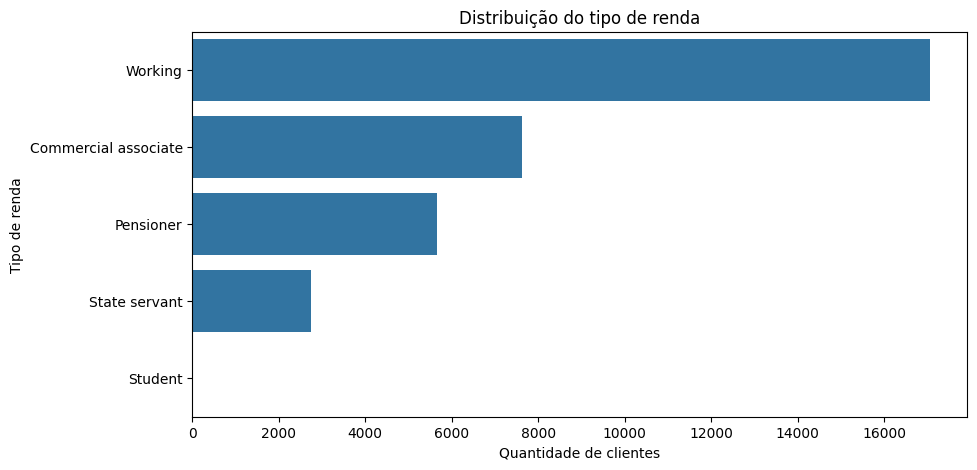

In [26]:
# ============================================================
# 21. DISTRIBUIÇÃO DO TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_INCOME_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Distribuição do tipo de renda")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de renda")

plt.show()

### Interpretação

A distribuição do tipo de renda é concentrada principalmente na categoria `Working`, que representa 51,58% dos clientes, seguida por `Commercial associate` (23,04%) e `Pensioner` (17,09%). `State servant` corresponde a 8,26% da base, enquanto `Student` representa apenas 0,03%, com 11 registros.

A distribuição evidencia forte predominância de clientes classificados como `Working` e baixa representatividade de algumas categorias. As categorias de baixa frequência serão consideradas posteriormente na etapa de pré-processamento, especialmente quanto à representação adequada das categorias na modelagem.

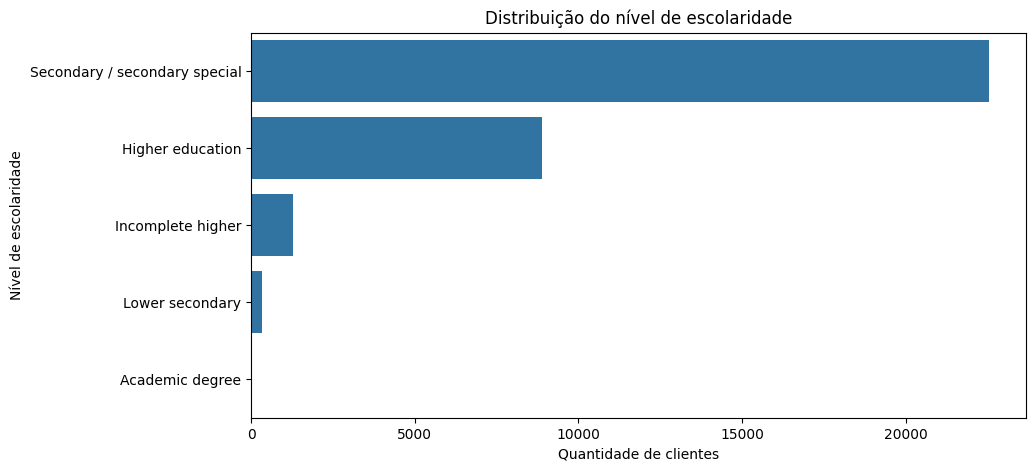

In [27]:
# ============================================================
# 22. DISTRIBUIÇÃO DO NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_EDUCATION_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Distribuição do nível de escolaridade")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Nível de escolaridade")

plt.show()

### Interpretação

A distribuição do nível de escolaridade apresenta forte concentração em duas categorias. `Secondary / secondary special` representa 68,12% dos clientes, enquanto `Higher education` corresponde a 26,85%. As demais categorias apresentam participação bastante reduzida: `Incomplete higher` representa 3,90%, `Lower secondary` 1,04% e `Academic degree` apenas 0,09% da base.

Essa concentração deve ser considerada posteriormente na codificação das variáveis categóricas, especialmente em relação às categorias de baixa frequência.

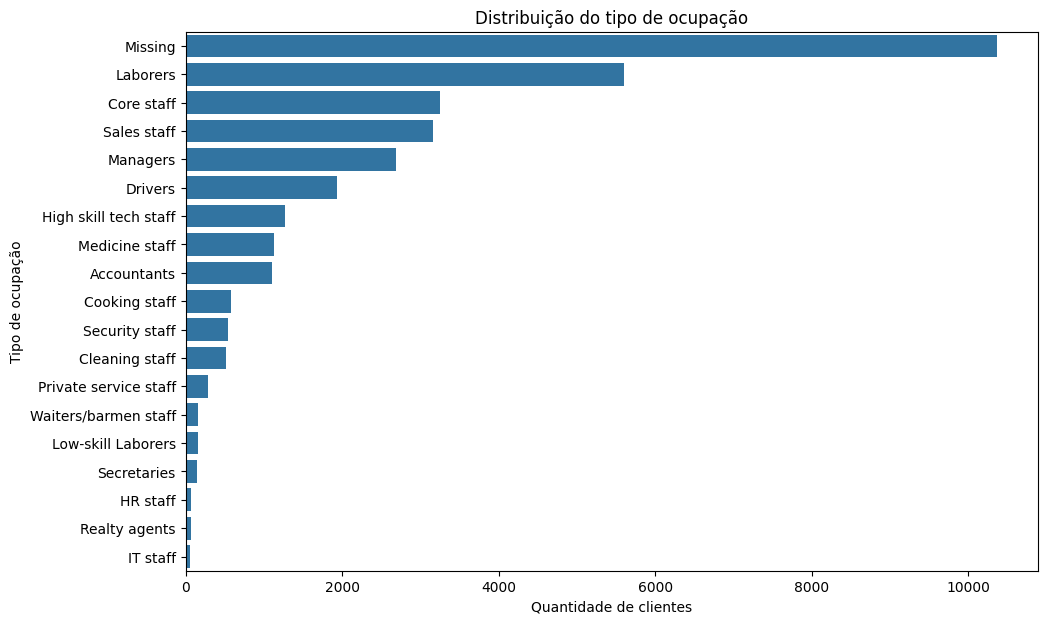

In [28]:
# ============================================================
# 23. DISTRIBUIÇÃO DO TIPO DE OCUPAÇÃO
# ============================================================

ocupacao_plot = df["OCCUPATION_TYPE"].fillna("Missing")

ordem_ocupacao = (
    ocupacao_plot
    .value_counts()
    .index
)

plt.figure(figsize=(11, 7))

sns.countplot(
    y=ocupacao_plot,
    order=ordem_ocupacao
)

plt.title("Distribuição do tipo de ocupação")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de ocupação")

plt.show()

### Interpretação

A distribuição de `OCCUPATION_TYPE` apresenta elevada concentração de valores ausentes. Os registros sem informação de ocupação correspondem a 10.373 clientes, ou 31,33% da base, constituindo a maior categoria individual da variável.

Entre os registros com ocupação informada, `Laborers` é a categoria mais frequente (16,92%), seguida por `Core staff` (9,82%), `Sales staff` (9,53%) e `Managers` (8,14%). Também existem diversas categorias com baixa frequência, algumas representando menos de 1% da base.

A elevada proporção de valores ausentes e a presença de categorias pouco frequentes são aspectos relevantes para o tratamento dessa variável. A estratégia de tratamento será definida posteriormente, na etapa de pré-processamento, sem alteração dos valores nesta etapa exploratória.

## 4 — Análise da variável-alvo

A variável `target` representa o evento definido na etapa de preparação dos dados. Nesta etapa será analisada sua distribuição, com atenção à proporção entre as classes e ao possível desbalanceamento da base.

In [29]:
# ============================================================
# 24. DISTRIBUIÇÃO DO TARGET
# ============================================================

contagem_target = df[TARGET].value_counts().sort_index()

percentual_target = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumo_target = pd.DataFrame({
    "quantidade": contagem_target,
    "percentual": percentual_target
})

resumo_target

,quantidade,percentual
target,,
0,28819,87.04
1,4291,12.96


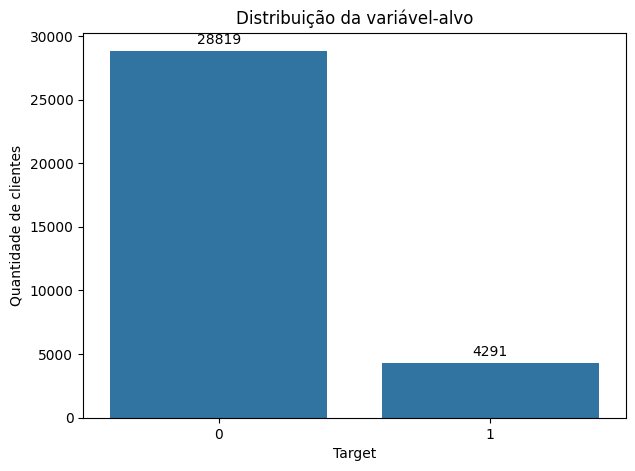

In [30]:
# ============================================================
# 25. VISUALIZAÇÃO DA DISTRIBUIÇÃO DO TARGET
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    order=[0, 1]
)

plt.title("Distribuição da variável-alvo")
plt.xlabel("Target")
plt.ylabel("Quantidade de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.show()

### Interpretação

A variável-alvo apresenta 28.819 clientes classificados como `0`, correspondentes a 87,04% da base, e 4.291 clientes classificados como `1`, correspondentes a 12,96%.

Observa-se, portanto, uma distribuição desigual entre as classes, com predominância da classe `0`. Essa característica deve ser considerada nas etapas posteriores de divisão da amostra, treinamento e avaliação dos modelos, especialmente na escolha das métricas de desempenho.

A distribuição do target será mantida sem alterações nesta etapa exploratória. Eventuais estratégias para lidar com o desbalanceamento serão avaliadas posteriormente no processo de modelagem.

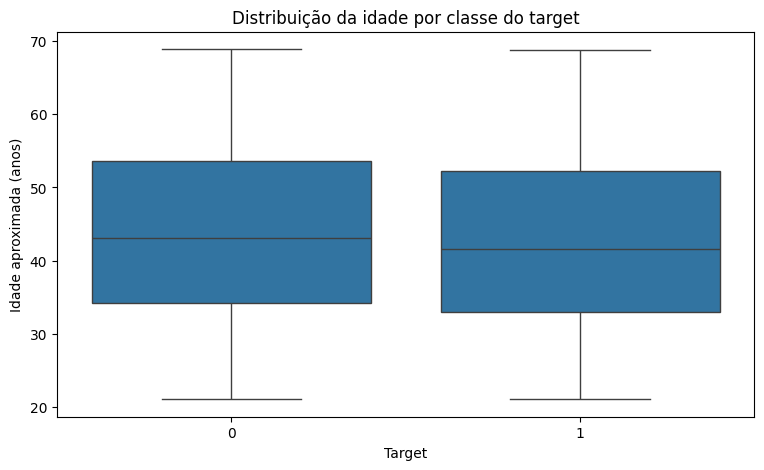

In [31]:
# ============================================================
# 26. IDADE POR CLASSE DO TARGET
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="AGE_YEARS"
)

plt.title("Distribuição da idade por classe do target")
plt.xlabel("Target")
plt.ylabel("Idade aproximada (anos)")

plt.show()

### Interpretação

A distribuição da idade apresenta diferenças entre as classes do target, embora exista considerável sobreposição entre os grupos. Visualmente, a mediana da idade é ligeiramente menor entre os clientes classificados como `target = 1` em comparação com `target = 0`.

As amplitudes e os intervalos interquartis dos dois grupos são semelhantes, indicando que a idade, isoladamente, não separa completamente as duas classes. A visualização evidencia uma diferença descritiva entre os grupos, mas não permite estabelecer relação causal entre idade e ocorrência do evento.

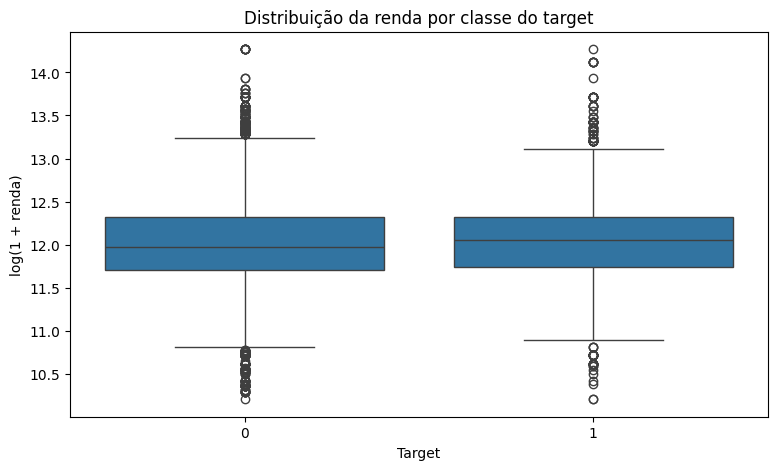

In [34]:
# ============================================================
# 27. RENDA POR CLASSE DO TARGET
# ============================================================

df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="LOG_INCOME"
)

plt.title("Distribuição da renda por classe do target")
plt.xlabel("Target")
plt.ylabel("log(1 + renda)")

plt.show()

### Interpretação

As distribuições da renda apresentam comportamento semelhante entre as duas classes do target, embora a mediana da renda no grupo `target = 1` seja ligeiramente superior à observada no grupo `target = 0`.

Também são observados valores extremos em ambas as classes, tanto na região inferior quanto na superior da distribuição. A utilização de `log(1 + renda)` nesta visualização reduz o efeito desses valores extremos sobre a escala do gráfico, permitindo uma comparação mais adequada entre os grupos.

A análise gráfica, isoladamente, não indica uma separação acentuada entre as classes com base apenas na renda. A variável original `AMT_INCOME_TOTAL` será preservada para as etapas posteriores.

In [35]:
# Remove variável criada exclusivamente para visualização
df.drop(columns=["LOG_INCOME"], inplace=True)

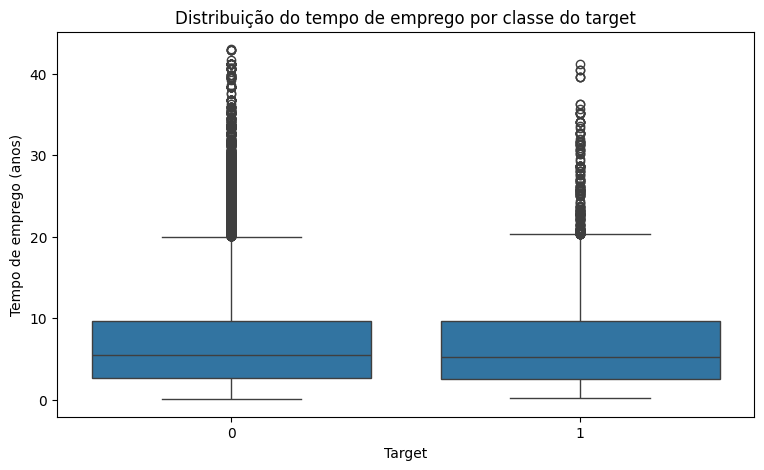

In [36]:
# ============================================================
# 28. TEMPO DE EMPREGO POR CLASSE DO TARGET
# ============================================================

df_emprego = df.loc[
    df["DAYS_EMPLOYED"] < 0
].copy()

df_emprego["EMPLOYMENT_YEARS"] = (
    -df_emprego["DAYS_EMPLOYED"] / 365.25
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_emprego,
    x=TARGET,
    y="EMPLOYMENT_YEARS"
)

plt.title("Distribuição do tempo de emprego por classe do target")
plt.xlabel("Target")
plt.ylabel("Tempo de emprego (anos)")

plt.show()

### Interpretação

Considerando somente os registros com valores interpretáveis de `DAYS_EMPLOYED`, as distribuições do tempo de emprego são semelhantes entre as duas classes do target. As medianas e os intervalos interquartis apresentam valores próximos, enquanto ambas as classes possuem uma cauda superior extensa, com observações de vínculos de longa duração.

A visualização não evidencia uma separação acentuada entre `target = 0` e `target = 1` com base exclusivamente no tempo de emprego. Os registros originalmente codificados como `365243` permanecem fora desta comparação e serão tratados posteriormente na etapa de pré-processamento.

In [37]:
# ============================================================
# 29. TAXA DO TARGET POR TIPO DE RENDA
# ============================================================

taxa_target_renda = (
    df.groupby("NAME_INCOME_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_renda["percentual_target_1"] = (
    taxa_target_renda["mean"] * 100
).round(2)

taxa_target_renda

,count,sum,mean,percentual_target_1
NAME_INCOME_TYPE,,,,
Commercial associate,7627,1080,0.141602,14.16
State servant,2736,385,0.140716,14.07
Working,17077,2181,0.127716,12.77
Pensioner,5659,644,0.113801,11.38
Student,11,1,0.090909,9.09


### Interpretação

As taxas observadas de `target = 1` apresentam diferenças entre os tipos de renda, variando de 9,09% a 14,16%. As maiores proporções foram observadas entre `Commercial associate` (14,16%) e `State servant` (14,07%), enquanto `Pensioner` apresentou 11,38% e `Working` 12,77%.

A categoria `Student` apresentou taxa de 9,09%, porém esse percentual corresponde a apenas 1 ocorrência em 11 clientes e, portanto, deve ser interpretado com cautela devido ao pequeno número de observações.

De forma geral, as diferenças observadas entre as categorias não são muito amplas. Esta análise é descritiva e não permite estabelecer relação causal entre o tipo de renda e a ocorrência do evento.

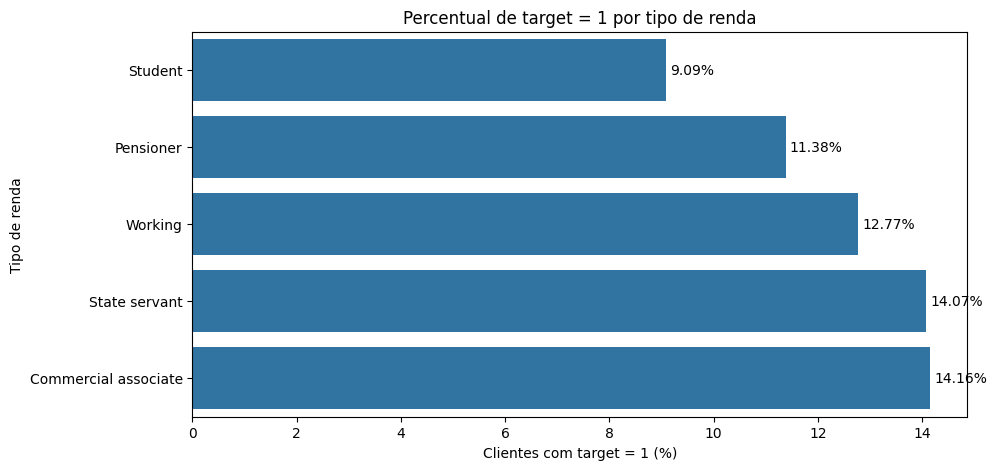

In [38]:
# ============================================================
# 30. TAXA DE TARGET = 1 POR TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = taxa_target_renda["percentual_target_1"].sort_values().index

ax = sns.barplot(
    data=taxa_target_renda.reset_index(),
    x="percentual_target_1",
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de renda")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de renda")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

As taxas de ocorrência de `target = 1` apresentam diferenças entre os tipos de renda, variando de 9,09% a 14,16%. As maiores taxas observadas foram de 14,16% para `Commercial associate` e 14,07% para `State servant`, enquanto `Working` apresentou 12,77% e `Pensioner` 11,38%.

A categoria `Student` apresentou 9,09%, mas corresponde a apenas 11 clientes, dos quais 1 apresentou `target = 1`. Portanto, essa taxa deve ser interpretada com cautela devido ao pequeno número de observações.

De forma geral, as taxas apresentam diferenças relativamente moderadas entre as categorias. A análise é descritiva e não permite estabelecer relação causal entre o tipo de renda e a ocorrência do evento.

In [39]:
# ============================================================
# 31. TAXA DO TARGET POR NÍVEL DE ESCOLARIDADE
# ============================================================

taxa_target_escolaridade = (
    df.groupby("NAME_EDUCATION_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_escolaridade["percentual_target_1"] = (
    taxa_target_escolaridade["mean"] * 100
).round(2)

taxa_target_escolaridade

,count,sum,mean,percentual_target_1
NAME_EDUCATION_TYPE,,,,
Academic degree,29,7,0.241379,24.14
Incomplete higher,1292,207,0.160217,16.02
Higher education,8891,1148,0.129119,12.91
Secondary / secondary special,22554,2890,0.128137,12.81
Lower secondary,344,39,0.113372,11.34


### Interpretação

As taxas observadas de `target = 1` variam entre os níveis de escolaridade. A maior taxa foi observada em `Academic degree` (24,14%), porém essa categoria possui apenas 29 clientes, dos quais 7 apresentaram o evento, o que exige cautela na interpretação.

Entre as categorias com maior número de observações, `Incomplete higher` apresentou 16,02%, enquanto `Higher education` e `Secondary / secondary special` apresentaram taxas próximas, de 12,91% e 12,81%, respectivamente. `Lower secondary` apresentou 11,34%.

As diferenças observadas são descritivas e não permitem estabelecer causalidade. Em particular, categorias com poucos registros podem apresentar taxas mais instáveis, motivo pelo qual seu tamanho amostral deve ser considerado conjuntamente com a taxa observada.

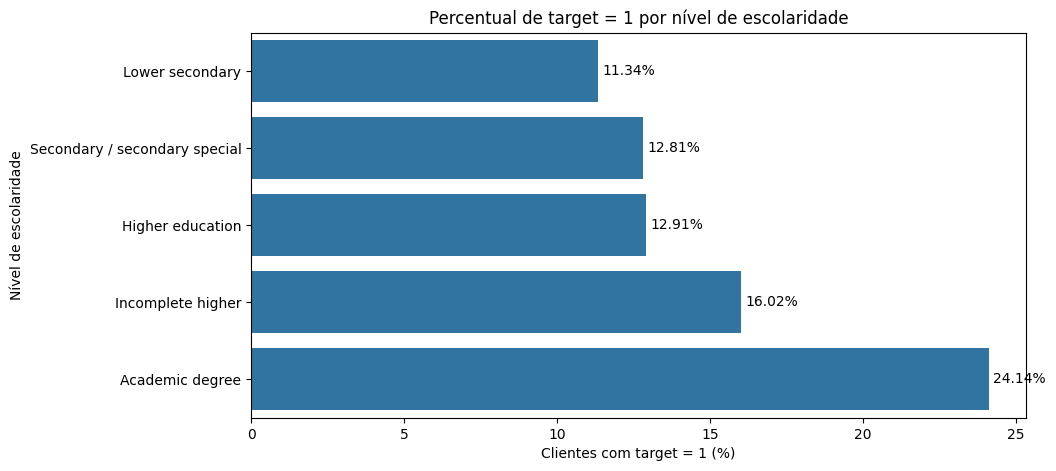

In [40]:
# ============================================================
# 32. TAXA DE TARGET = 1 POR NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    taxa_target_escolaridade["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_escolaridade.reset_index(),
    x="percentual_target_1",
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por nível de escolaridade")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Nível de escolaridade")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

A categoria `Academic degree` apresenta a maior taxa observada, mas também possui o menor número de observações, o que reduz a estabilidade dessa estimativa. Portanto, as taxas devem ser analisadas conjuntamente com o tamanho de cada grupo.

In [41]:
# ============================================================
# 33. TAXA DO TARGET POR ESTADO CIVIL
# ============================================================

taxa_target_estado_civil = (
    df.groupby("NAME_FAMILY_STATUS")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_estado_civil["percentual_target_1"] = (
    taxa_target_estado_civil["mean"] * 100
).round(2)

taxa_target_estado_civil

,count,sum,mean,percentual_target_1
NAME_FAMILY_STATUS,,,,
Single / not married,4433,623,0.140537,14.05
Civil marriage,2656,367,0.138178,13.82
Married,22725,2914,0.128229,12.82
Separated,1908,225,0.117925,11.79
Widow,1388,162,0.116715,11.67


### Interpretação

As taxas de `target = 1` apresentam variação relativamente pequena entre as categorias de estado civil, situando-se entre 11,67% e 14,05%. A maior taxa foi observada entre clientes classificados como `Single / not married` (14,05%), seguida por `Civil marriage` (13,82%).

A categoria `Married`, que representa a maior parte da base, apresentou taxa de 12,82%. `Separated` e `Widow` apresentaram taxas de 11,79% e 11,67%, respectivamente.

As diferenças observadas são descritivas e não indicam, isoladamente, uma relação causal entre estado civil e ocorrência do evento.

In [42]:
# ============================================================
# 34. TAXA DO TARGET POR TIPO DE OCUPAÇÃO
# ============================================================

df["OCCUPATION_TYPE_EDA"] = df["OCCUPATION_TYPE"].fillna("Missing")

taxa_target_ocupacao = (
    df.groupby("OCCUPATION_TYPE_EDA")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_ocupacao["percentual_target_1"] = (
    taxa_target_ocupacao["mean"] * 100
).round(2)

taxa_target_ocupacao

,count,sum,mean,percentual_target_1
OCCUPATION_TYPE_EDA,,,,
Low-skill Laborers,159,33,0.207547,20.75
IT staff,57,11,0.192982,19.30
HR staff,76,14,0.184211,18.42
Security staff,547,91,0.166362,16.64
Realty agents,67,10,0.149254,14.93
Cooking staff,587,86,0.146508,14.65
Medicine staff,1124,163,0.145018,14.50
Managers,2695,390,0.144712,14.47
High skill tech staff,1269,181,0.142632,14.26


### Interpretação

As taxas de `target = 1` apresentam variação entre as categorias de ocupação. Algumas categorias com poucos registros apresentam taxas relativamente elevadas, como `Low-skill Laborers` (20,75%), `IT staff` (19,30%) e `HR staff` (18,42%). Entretanto, essas categorias possuem tamanhos amostrais reduzidos, respectivamente 159, 57 e 76 clientes, o que recomenda cautela na interpretação dessas taxas.

Entre as categorias com maior quantidade de observações, `Managers` apresentou 14,47%, `Core staff` 14,25%, `Drivers` 13,65% e `Laborers` 13,03%. Já os clientes sem informação de ocupação (`Missing`) apresentaram taxa de 11,59%, correspondendo a 10.373 clientes.

A análise evidencia que a frequência da categoria deve ser considerada conjuntamente com a taxa observada. As diferenças são descritivas e não permitem estabelecer relação causal entre ocupação e ocorrência do evento.

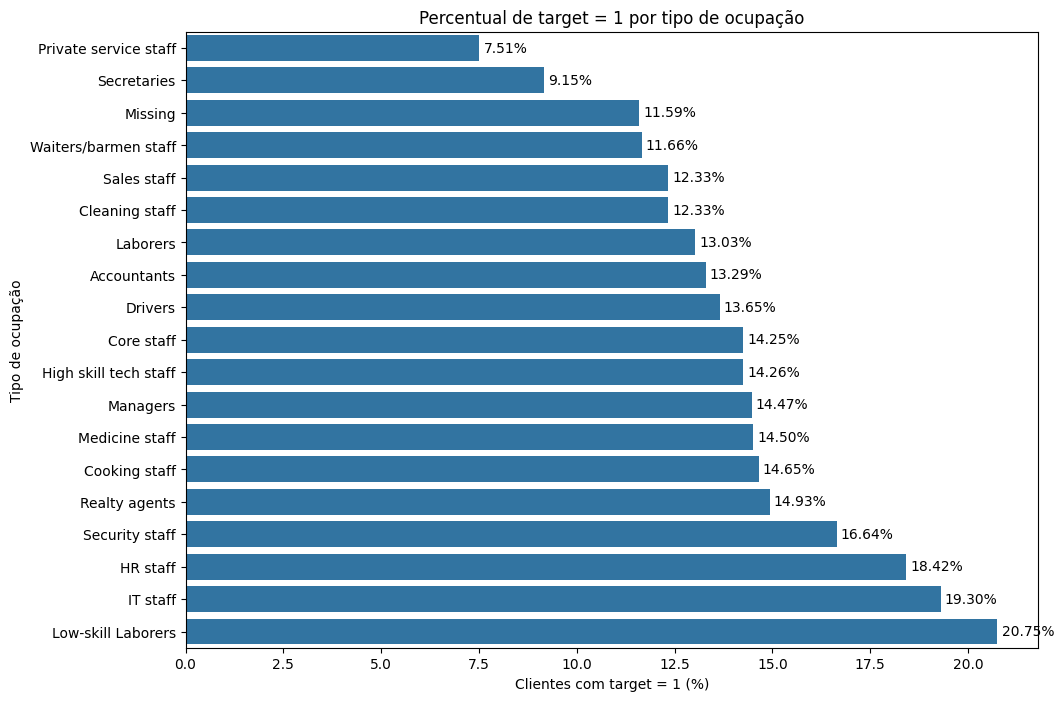

In [43]:
# ============================================================
# 35. TAXA DE TARGET = 1 POR TIPO DE OCUPAÇÃO
# ============================================================

plt.figure(figsize=(11, 8))

ordem = (
    taxa_target_ocupacao["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_ocupacao.reset_index(),
    x="percentual_target_1",
    y="OCCUPATION_TYPE_EDA",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de ocupação")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de ocupação")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

In [45]:
# Remove variável criada exclusivamente para o EDA
df.drop(columns=["OCCUPATION_TYPE_EDA"], inplace=True)

KeyError: "['OCCUPATION_TYPE_EDA'] not found in axis"

## 5 — Relações entre variáveis
Nesta etapa são analisadas as relações entre as principais variáveis quantitativas da base, com o objetivo de identificar associações relevantes e possíveis redundâncias entre as variáveis explicativas.

In [46]:
# ============================================================
# 36. CORRELAÇÃO ENTRE VARIÁVEIS QUANTITATIVAS
# ============================================================

variaveis_correlacao = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS",
    TARGET
]

matriz_corr = df[variaveis_correlacao].corr()

matriz_corr.round(3)

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,target
CNT_CHILDREN,1.000,0.038,0.341,-0.231,0.888,0.014
AMT_INCOME_TOTAL,0.038,1.000,0.071,-0.166,0.025,0.029
DAYS_BIRTH,0.341,0.071,1.000,-0.616,0.303,0.033
DAYS_EMPLOYED,-0.231,-0.166,-0.616,1.000,-0.219,-0.025
CNT_FAM_MEMBERS,0.888,0.025,0.303,-0.219,1.000,0.011
target,0.014,0.029,0.033,-0.025,0.011,1.000


### Interpretação

A matriz de correlação evidencia uma forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,888), indicando possível redundância entre essas variáveis. Também foi observada correlação de -0,616 entre `DAYS_BIRTH` e `DAYS_EMPLOYED`, enquanto as demais associações entre variáveis quantitativas são predominantemente baixas ou moderadas.

As correlações lineares individuais com a variável-alvo são baixas. Entretanto, esses valores não devem ser utilizados isoladamente para avaliar o potencial preditivo das variáveis, pois o `target` é binário e relações não lineares ou efeitos combinados entre variáveis podem não ser capturados pela correlação de Pearson.

A forte correlação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` será considerada nas etapas posteriores de pré-processamento e modelagem.

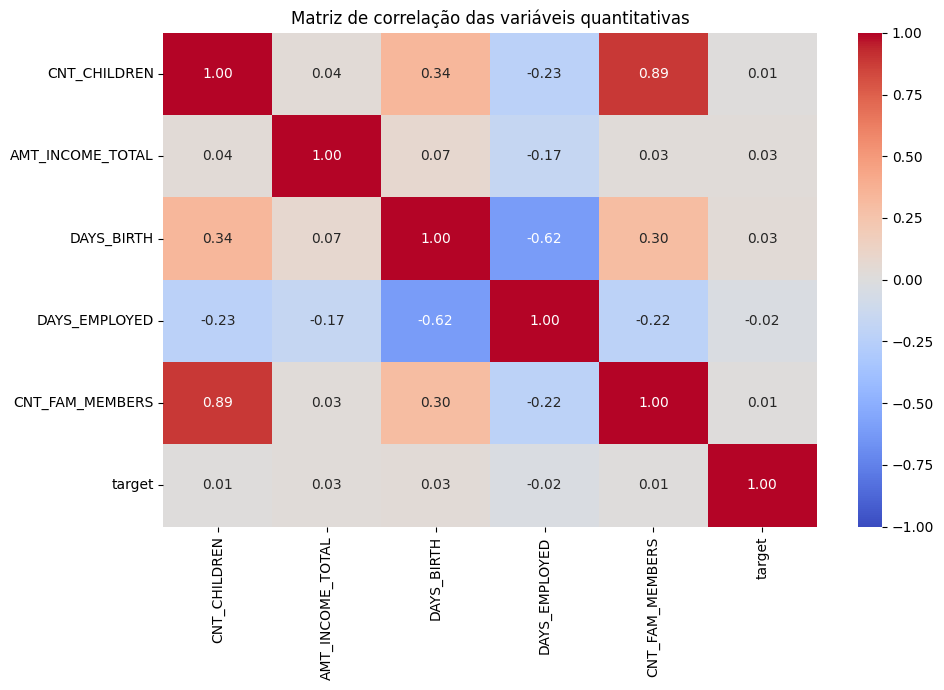

In [47]:
# ============================================================
# 37. HEATMAP DA MATRIZ DE CORRELAÇÃO
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlação das variáveis quantitativas")
plt.tight_layout()
plt.show()

### Interpretação

O heatmap confirma a forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,89), indicando possível redundância entre essas variáveis. Também se observa uma associação negativa de magnitude moderada a forte entre `DAYS_BIRTH` e `DAYS_EMPLOYED` (-0,62).

As demais correlações entre as variáveis quantitativas são relativamente baixas. As correlações individuais com o `target` também apresentam baixa magnitude, variando aproximadamente entre -0,03 e 0,03. Entretanto, esses valores não devem ser utilizados isoladamente para avaliar o potencial preditivo das variáveis, pois o `target` é binário e relações não lineares ou efeitos combinados podem não ser capturados pela correlação de Pearson.

A forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` deverá ser considerada nas etapas posteriores de pré-processamento e modelagem.

## 6. Síntese da EDA

A análise exploratória foi realizada sobre uma base com 33.110 clientes, sem registros duplicados e sem valores ausentes na variável-alvo. O `target` apresenta distribuição desbalanceada, com 28.819 clientes (87,04%) classificados como `0` e 4.291 (12,96%) como `1`. Essa característica deve ser considerada nas etapas posteriores de modelagem e avaliação.

A população analisada apresenta idade média de aproximadamente 43,8 anos, com distribuição entre cerca de 21 e 69 anos. A renda total possui forte assimetria à direita, com concentração das observações em valores mais baixos e uma cauda formada por clientes com rendas elevadas. A mediana da renda é de R$ 157.500, enquanto o percentil 99 corresponde a R$ 560.250, indicando a presença de valores extremos que deverão ser considerados no pré-processamento.

O tempo de emprego também apresenta distribuição assimétrica. Foi identificada uma codificação específica (`DAYS_EMPLOYED = 365243`) correspondente a 5.642 registros (17,04%), que não representa um tempo de emprego interpretável e deverá receber tratamento específico. Considerando somente os registros com tempo de emprego válido, a mediana é de aproximadamente 5,5 anos.

Entre as variáveis categóricas, observa-se predominância de clientes do sexo feminino (67,11%), proprietários de imóveis (67,32%) e clientes sem veículo próprio (62,27%). A maior parte dos clientes possui ensino secundário ou equivalente (68,12%), é casada (68,63%) e reside em casa ou apartamento (89,34%). Quanto ao tipo de renda, predominam clientes classificados como `Working` (51,58%) e `Commercial associate` (23,04%).

Um dos principais pontos de atenção identificados foi `OCCUPATION_TYPE`, que apresenta 10.373 registros ausentes, correspondentes a 31,33% da base. A análise da taxa do target por categoria mostrou diferenças entre os grupos, mas categorias com poucos registros apresentaram taxas mais instáveis. Assim, o tratamento dos valores ausentes e das categorias de baixa frequência deverá considerar não apenas a distribuição da variável, mas também os impactos sobre a modelagem.

Na análise bivariada com o target, as diferenças observadas nas variáveis categóricas foram relativamente moderadas. Por exemplo, as taxas de `target = 1` variaram de 11,38% a 14,16% entre os tipos de renda e de 11,67% a 14,05% entre os estados civis. Na escolaridade, algumas categorias apresentaram taxas mais elevadas, mas aquelas com poucos registros exigem cautela na interpretação. A análise da ocupação apresentou maior amplitude entre as taxas, porém também revelou categorias com tamanhos amostrais reduzidos.

Entre as variáveis quantitativas, as distribuições de idade, renda e tempo de emprego apresentaram características distintas, como assimetria e presença de valores extremos. A comparação das distribuições por classe do target não revelou, visualmente, uma separação acentuada entre as classes apenas por idade, renda ou tempo de emprego.

Por fim, a análise de correlação identificou forte associação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,89), indicando possível redundância entre essas variáveis. Também foi observada correlação de -0,62 entre `DAYS_BIRTH` e `DAYS_EMPLOYED`. As correlações lineares individuais com o target foram baixas, mas esse resultado não deve ser interpretado como ausência de capacidade preditiva, uma vez que o target é binário e relações não lineares ou efeitos combinados podem não ser capturados pela correlação de Pearson.

De forma geral, a EDA indica que a base apresenta três desafios principais para as próximas etapas: **desbalanceamento do target, tratamento de valores e códigos especiais — especialmente em `DAYS_EMPLOYED` e `OCCUPATION_TYPE` — e possível redundância entre algumas variáveis quantitativas**. Esses achados orientarão o pré-processamento e a construção dos modelos preditivos nas etapas seguintes.